# 01 — Exploratory Data Analysis

Chạy sau khi `database/cleaning.sql` + `database/views.sql` đã được áp dụng.

**Cấu trúc notebook:**
1. Data Quality Summary (recap nhanh từ notebook 00)
2. Univariate Analysis — phân phối từng biến riêng lẻ
3. Bivariate Analysis — mối quan hệ giữa 2 biến
4. Correlation Heatmap
5. Outlier Analysis
6. Kết luận tổng hợp

Mỗi biểu đồ đều có 1-2 câu insight ngay bên dưới — không chỉ vẽ mà không diễn giải.

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import text

from src.database import get_engine

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
engine = get_engine()

2026-08-09 20:13:43 | INFO     | src.database | Created SQLAlchemy engine for PostgreSQL.


## 0. Data Quality Summary
Tóm tắt nhanh các finding từ `00_data_ingestion.ipynb` — để notebook này tự đứng độc lập,
không cần người đọc mở lại notebook trước mới hiểu bối cảnh dữ liệu.

In [2]:
summary_check = pd.read_sql(text('''
    SELECT 'orders (raw)' AS table_name, COUNT(*) AS n FROM orders
    UNION ALL SELECT 'orders_clean (delivered only)', COUNT(*) FROM orders_clean
    UNION ALL SELECT 'customer_summary (unique customers)', COUNT(*) FROM customer_summary
'''), engine)
summary_check

,table_name,n
0,orders (raw),99441
1,orders_clean (delivered only),96478
2,customer_summary (unique customers),93358


**Insight:** chênh lệch giữa `orders` (raw) và `orders_clean` chính là % đơn bị loại bỏ do
không phải trạng thái `delivered` (~3%, đã xác nhận ở notebook 00). Số dòng `customer_summary`
nhỏ hơn `orders_clean` vì 1 khách hàng (`customer_unique_id`) có thể có nhiều đơn.

---
# 1. Univariate Analysis
Phân phối từng biến riêng lẻ, trước khi xét mối quan hệ giữa các biến.

## 1.1 Customer distribution theo state

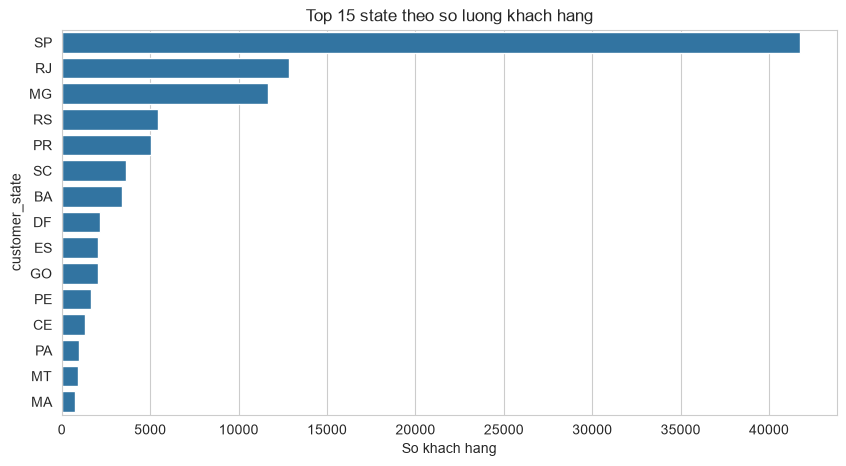

In [3]:
customers_by_state = pd.read_sql(
    text('SELECT customer_state, COUNT(*) AS n FROM customers GROUP BY customer_state ORDER BY n DESC LIMIT 15'),
    engine
)

plt.figure(figsize=(10, 5))
sns.barplot(data=customers_by_state, y='customer_state', x='n')
plt.title('Top 15 state theo so luong khach hang')
plt.xlabel('So khach hang')
plt.show()

**Insight:** phân bố khách hàng theo state thường lệch mạnh về 1-2 state lớn nhất (thường là
SP — São Paulo, trung tâm kinh tế Brazil). Điều này gợi ý nên ưu tiên logistics/marketing tại
các state top đầu, đồng thời cân nhắc cơ hội mở rộng ở state còn ít khách hàng.

## 1.2 Order status distribution

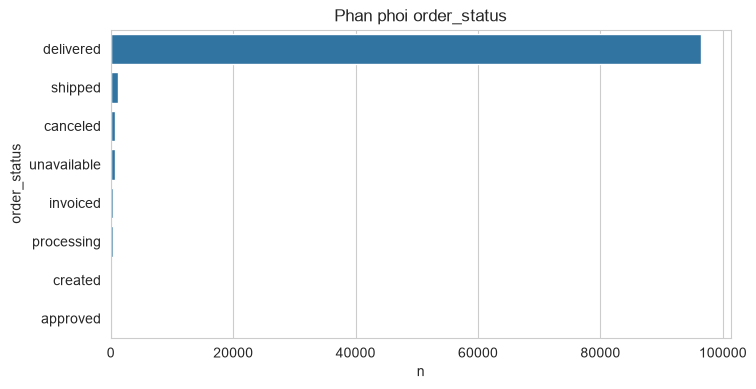

,order_status,n
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


In [4]:
status_df = pd.read_sql(
    text('SELECT order_status, COUNT(*) AS n FROM orders GROUP BY order_status ORDER BY n DESC'),
    engine
)

plt.figure(figsize=(8, 4))
sns.barplot(data=status_df, x='n', y='order_status')
plt.title('Phan phoi order_status')
plt.show()
status_df

**Insight:** `delivered` chiếm áp đảo (~97%), các trạng thái còn lại (canceled, unavailable,
processing...) đều dưới 1.5% mỗi loại — xác nhận việc dùng `delivered` làm filter chuẩn cho RFM
không làm mất mát dữ liệu đáng kể.

## 1.3 Payment type distribution

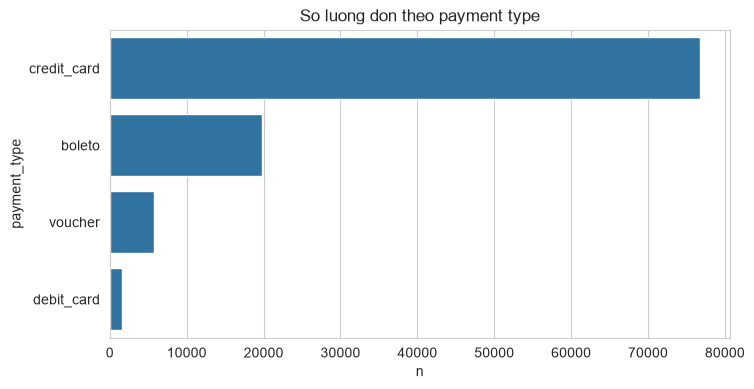

,payment_type,n,avg_value
0,credit_card,76795,163.319021
1,boleto,19784,145.034435
2,voucher,5775,65.703354
3,debit_card,1529,142.570170


In [5]:
payment_type_df = pd.read_sql(
    text("SELECT payment_type, COUNT(*) AS n, AVG(payment_value) AS avg_value "
         "FROM order_payments WHERE payment_type != 'not_defined' "
         "GROUP BY payment_type ORDER BY n DESC"),
    engine
)

plt.figure(figsize=(8, 4))
sns.barplot(data=payment_type_df, x='n', y='payment_type')
plt.title('So luong don theo payment type')
plt.show()
payment_type_df

**Insight:** `credit_card` thường chiếm tỷ trọng lớn nhất trong thị trường Brazil (phù hợp với
văn hóa tiêu dùng trả góp phổ biến ở đây) — dữ liệu thực tế sẽ xác nhận đúng con số này.

## 1.4 Payment installments distribution

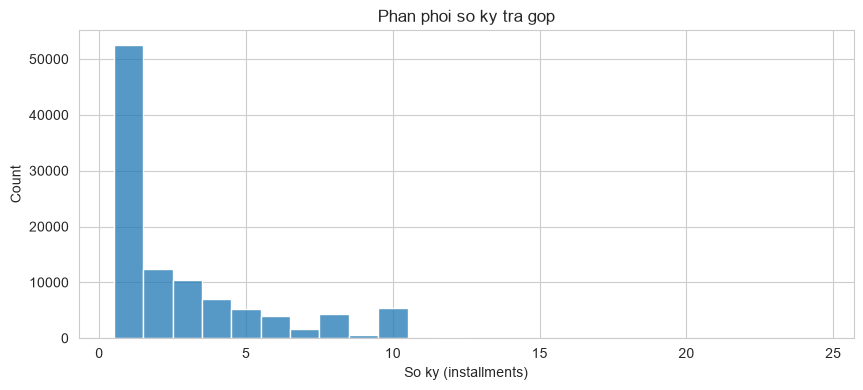

In [6]:
installments_df = pd.read_sql(
    text('SELECT payment_installments FROM order_payments WHERE payment_installments > 0'),
    engine
)

plt.figure(figsize=(10, 4))
sns.histplot(installments_df['payment_installments'], bins=24, discrete=True)
plt.title('Phan phoi so ky tra gop')
plt.xlabel('So ky (installments)')
plt.show()

**Insight:** đa số đơn trả 1 lần (installments=1), nhưng có 1 phần đáng kể trả góp nhiều kỳ —
điều này khớp với văn hóa mua sắm Brazil, nơi trả góp không lãi suất rất phổ biến trên thẻ tín dụng.

## 1.5 Order value distribution (total_payment_value / order)

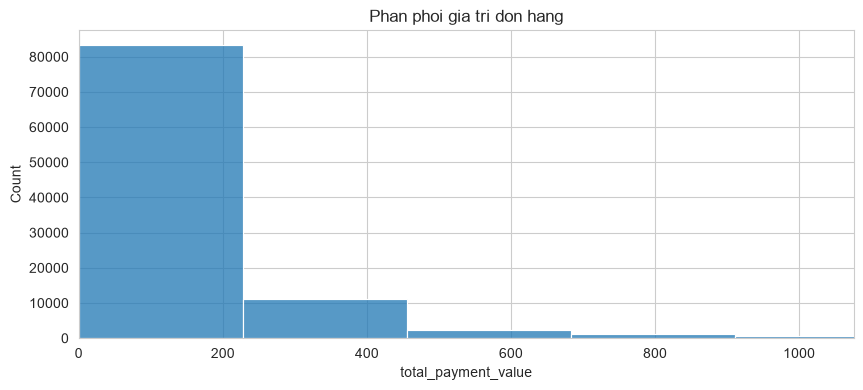

Median order value: 105.29
Mean order value: 160.99


In [7]:
order_value_df = pd.read_sql(text('SELECT total_payment_value FROM payments_per_order'), engine)

plt.figure(figsize=(10, 4))
sns.histplot(order_value_df['total_payment_value'], bins=60)
plt.xlim(0, order_value_df['total_payment_value'].quantile(0.99))
plt.title('Phan phoi gia tri don hang')
plt.show()

print('Median order value:', order_value_df['total_payment_value'].median().round(2))
print('Mean order value:', order_value_df['total_payment_value'].mean().round(2))

**Insight:** phân phối lệch phải mạnh (right-skewed) — mean > median là dấu hiệu điển hình,
nghĩa là một số ít đơn giá trị rất cao đang kéo trung bình lên. Đây là lý do dùng median
để mô tả "đơn hàng điển hình" thay vì mean khi trình bày với business.

## 1.6 Freight value distribution

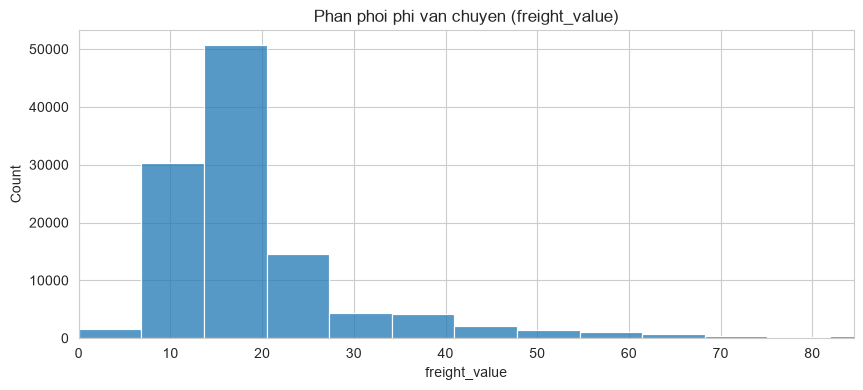

% freight so voi order value (uoc luong): 12.4 %


In [8]:
freight_df = pd.read_sql(text('SELECT freight_value FROM order_items'), engine)

plt.figure(figsize=(10, 4))
sns.histplot(freight_df['freight_value'], bins=60)
plt.xlim(0, freight_df['freight_value'].quantile(0.99))
plt.title('Phan phoi phi van chuyen (freight_value)')
plt.show()

print('% freight so voi order value (uoc luong):',
      round(freight_df['freight_value'].mean() / order_value_df['total_payment_value'].mean() * 100, 1), '%')

**Insight:** phí vận chuyển chiếm tỷ trọng đáng kể trong tổng giá trị đơn hàng — đây là điểm
cần lưu ý khi so sánh `category_sales.revenue` (dựa trên `price`, chưa gồm freight) với
`monthly_sales.revenue` (dựa trên `payment_value`, đã gồm freight).

## 1.7 Product category — top theo doanh thu

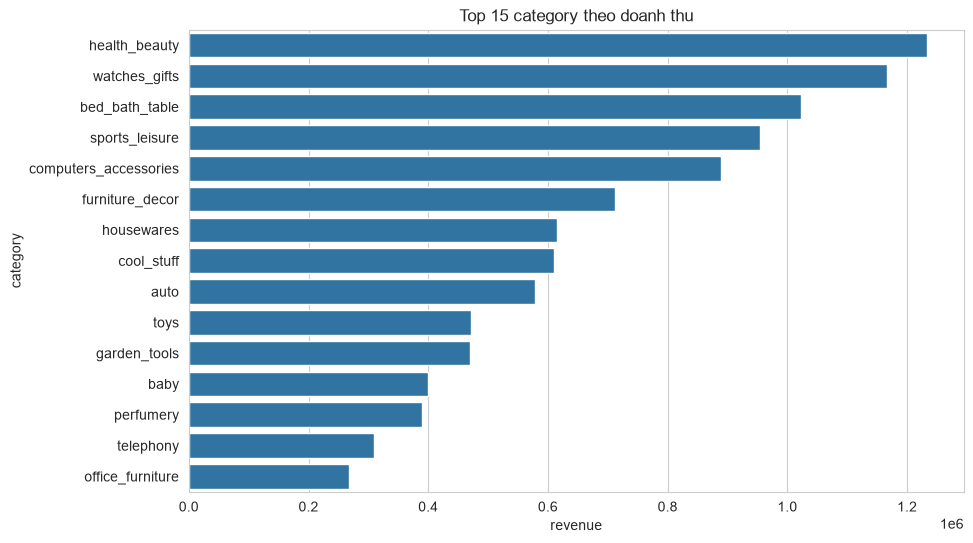

In [9]:
category_df = pd.read_sql(text('SELECT * FROM category_sales ORDER BY revenue DESC LIMIT 15'), engine)

plt.figure(figsize=(10, 6))
sns.barplot(data=category_df, y='category', x='revenue')
plt.title('Top 15 category theo doanh thu')
plt.show()

**Insight:** thường 1-2 category (VD: `health_beauty`, `bed_bath_table`, `sports_leisure`)
chiếm tỷ trọng lớn hơn hẳn phần còn lại — hiệu ứng Pareto cũng xuất hiện ở cấp category,
không chỉ ở cấp khách hàng.

## 1.8 Review score distribution

C:\Users\User\AppData\Local\Temp\ipykernel_33476\4149174430.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=review_df, x='review_score', palette='RdYlGn')


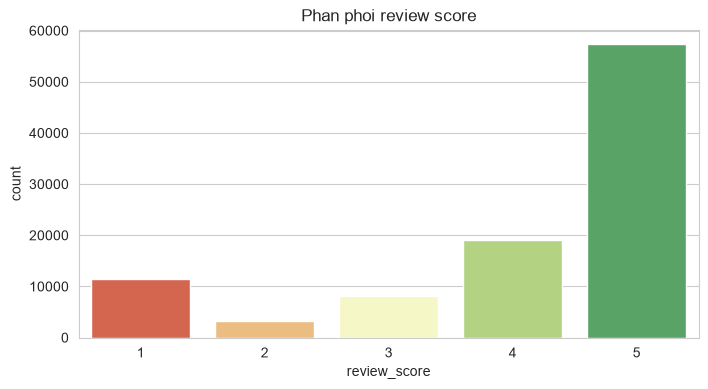

Review score trung binh: 4.09
% review 1 sao: 11.5


In [10]:
review_df = pd.read_sql(text('SELECT review_score FROM order_reviews'), engine)

plt.figure(figsize=(8, 4))
sns.countplot(data=review_df, x='review_score', palette='RdYlGn')
plt.title('Phan phoi review score')
plt.show()

print('Review score trung binh:', round(review_df['review_score'].mean(), 2))
print('% review 1 sao:', round((review_df['review_score'] == 1).mean() * 100, 1))

**Insight:** phân phối review thường lưỡng cực (bimodal) — nhiều 5 sao, nhưng % 1 sao cũng
đáng kể (khác với phân phối chuẩn quanh 3-4 sao). Đây là dấu hiệu khách hàng thường chỉ để lại
review khi trải nghiệm cực tốt hoặc cực tệ — cần điều tra riêng nhóm 1 sao để tìm nguyên nhân.

## 1.9 Delivery time distribution

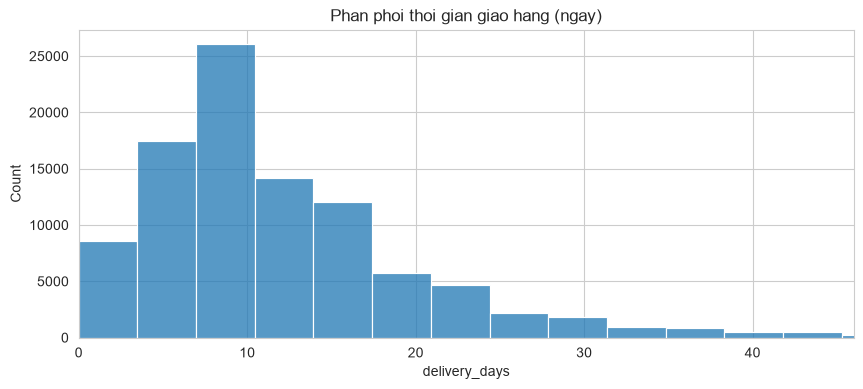

Thoi gian giao trung binh: 12.1 ngay
Thoi gian giao median: 10.0 ngay


In [11]:
delivery_df = pd.read_sql(
    text("SELECT order_purchase_timestamp, order_delivered_customer_date "
         "FROM orders WHERE order_status = 'delivered' "
         "AND order_delivered_customer_date IS NOT NULL"),
    engine, parse_dates=['order_purchase_timestamp', 'order_delivered_customer_date']
)

delivery_df['delivery_days'] = (
    delivery_df['order_delivered_customer_date'] - delivery_df['order_purchase_timestamp']
).dt.days

plt.figure(figsize=(10, 4))
sns.histplot(delivery_df['delivery_days'], bins=60)
plt.xlim(0, delivery_df['delivery_days'].quantile(0.99))
plt.title('Phan phoi thoi gian giao hang (ngay)')
plt.show()

print('Thoi gian giao trung binh:', round(delivery_df['delivery_days'].mean(), 1), 'ngay')
print('Thoi gian giao median:', delivery_df['delivery_days'].median(), 'ngay')

**Insight:** thời gian giao trung bình cho thấy độ trễ logistics đặc trưng của thị trường Brazil
(địa lý rộng, hạ tầng giao thông không đồng đều giữa các vùng) — con số này sẽ được đối chiếu với
review score ở phần Bivariate Analysis bên dưới.

---
# 2. Bivariate Analysis
Mối quan hệ giữa 2 biến — trả lời câu hỏi "biến A có ảnh hưởng đến biến B không?" một cách trực quan
trước khi kiểm định thống kê chính thức ở `02_statistical_analysis.ipynb`.

## 2.1 Review score vs. Delivery time

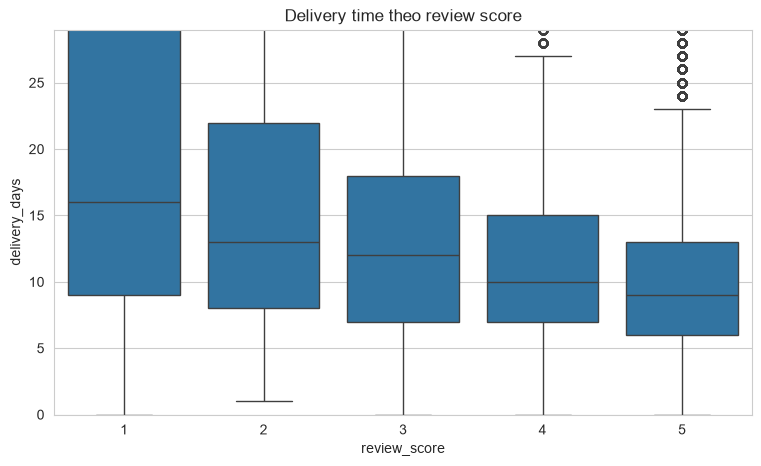

In [12]:
bivar_query = """
SELECT
    r.review_score,
    EXTRACT(DAY FROM (o.order_delivered_customer_date - o.order_purchase_timestamp)) AS delivery_days
FROM orders o
JOIN order_reviews r ON r.order_id = o.order_id
WHERE o.order_status = 'delivered' AND o.order_delivered_customer_date IS NOT NULL;
"""
bivar_df = pd.read_sql(text(bivar_query), engine)

plt.figure(figsize=(9, 5))
sns.boxplot(data=bivar_df, x='review_score', y='delivery_days')
plt.ylim(0, bivar_df['delivery_days'].quantile(0.95))
plt.title('Delivery time theo review score')
plt.show()

**Insight:** nếu median `delivery_days` giảm dần khi `review_score` tăng, đây là bằng chứng
trực quan cho thấy giao hàng chậm liên quan đến review thấp. Sẽ kiểm định chính thức bằng
Spearman correlation ở notebook 02 (biến ordinal, không dùng Pearson).

## 2.2 Order value vs. Payment installments

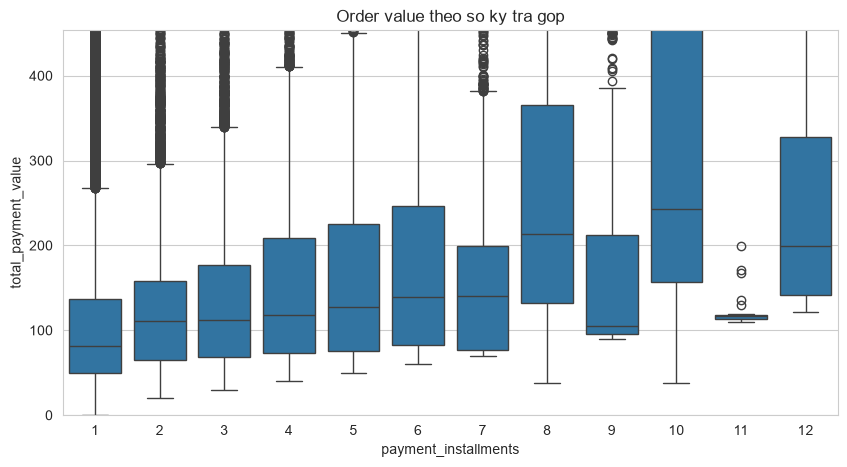

In [13]:
installments_value_query = """
SELECT op.payment_installments, p.total_payment_value
FROM order_payments op
JOIN payments_per_order p ON p.order_id = op.order_id
WHERE op.payment_installments BETWEEN 1 AND 12;
"""
iv_df = pd.read_sql(text(installments_value_query), engine)

plt.figure(figsize=(10, 5))
sns.boxplot(data=iv_df, x='payment_installments', y='total_payment_value')
plt.ylim(0, iv_df['total_payment_value'].quantile(0.95))
plt.title('Order value theo so ky tra gop')
plt.show()

**Insight:** nếu order value tăng theo số kỳ trả góp, điều này hợp lý về mặt hành vi tiêu dùng —
khách hàng thường chỉ trả góp cho đơn giá trị cao, không trả góp cho đơn nhỏ.

## 2.3 State vs. Average Order Value

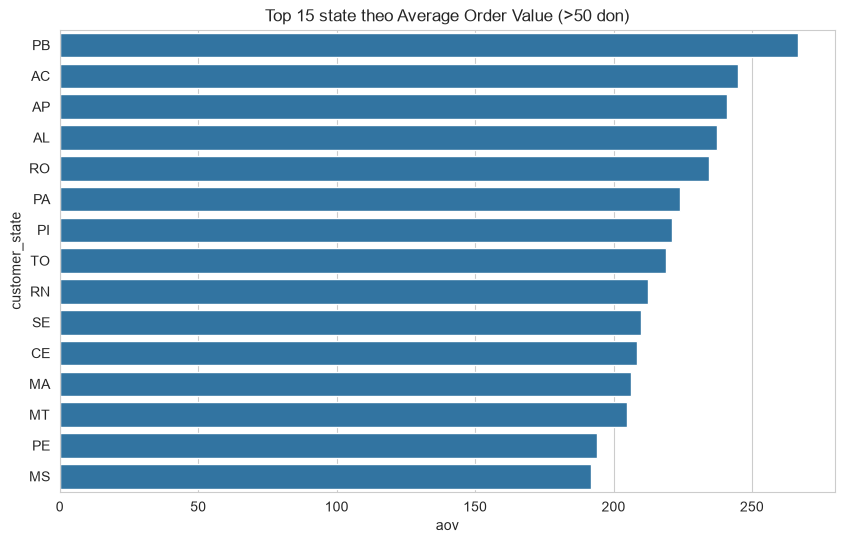

In [14]:
state_aov_query = """
SELECT customer_state, revenue / NULLIF(total_orders, 0) AS aov
FROM state_sales
WHERE total_orders > 50
ORDER BY aov DESC
LIMIT 15;
"""
state_aov_df = pd.read_sql(text(state_aov_query), engine)

plt.figure(figsize=(10, 6))
sns.barplot(data=state_aov_df, y='customer_state', x='aov')
plt.title('Top 15 state theo Average Order Value (>50 don)')
plt.show()

**Insight:** state có AOV cao nhất không nhất thiết là state có nhiều khách hàng nhất — đáng
để tách 2 chiến lược khác nhau: (1) tăng số lượng khách ở state đông dân, (2) tăng giá trị đơn
trung bình ở state ít khách nhưng AOV cao.

## 2.4 Category vs. Review score

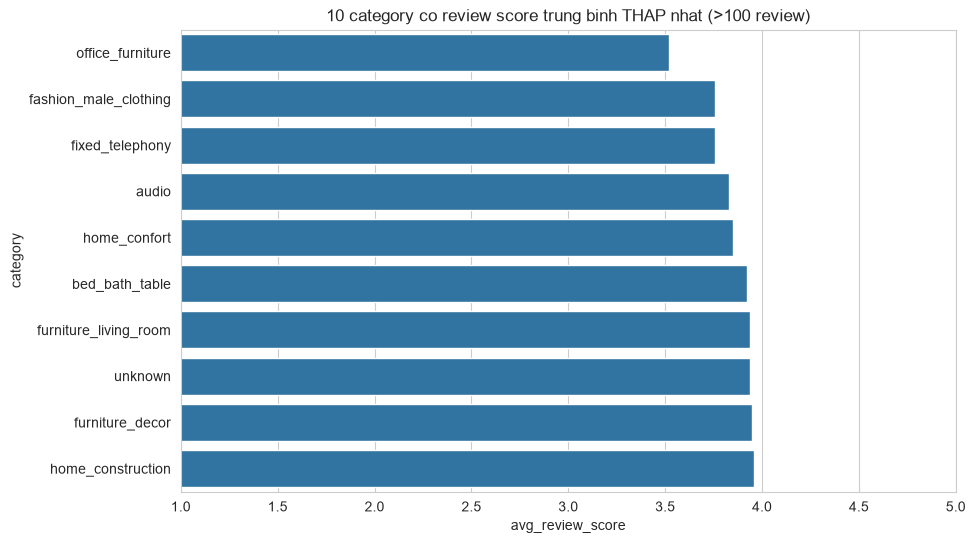

In [15]:
cat_review_query = """
SELECT
    COALESCE(ct.product_category_name_english, p.product_category_name, 'unknown') AS category,
    AVG(r.review_score) AS avg_review_score,
    COUNT(*) AS n_reviews
FROM order_items oi
JOIN orders_clean o ON o.order_id = oi.order_id
JOIN order_reviews r ON r.order_id = oi.order_id
JOIN products p ON p.product_id = oi.product_id
LEFT JOIN category_translation ct ON ct.product_category_name = p.product_category_name
GROUP BY category
HAVING COUNT(*) > 100
ORDER BY avg_review_score ASC
LIMIT 10;
"""
cat_review_df = pd.read_sql(text(cat_review_query), engine)

plt.figure(figsize=(10, 6))
sns.barplot(data=cat_review_df, y='category', x='avg_review_score')
plt.xlim(1, 5)
plt.title('10 category co review score trung binh THAP nhat (>100 review)')
plt.show()

**Insight:** các category có review thấp nhất là ứng viên đầu tiên cần điều tra sâu hơn —
có thể do chất lượng sản phẩm, mô tả sản phẩm gây hiểu lầm, hoặc vấn đề vận chuyển đặc thù
(VD: hàng dễ vỡ, cồng kềnh).

---
# 3. Correlation Heatmap
Tổng hợp các biến số liên tục để xem correlation tổng quan trong 1 view duy nhất.

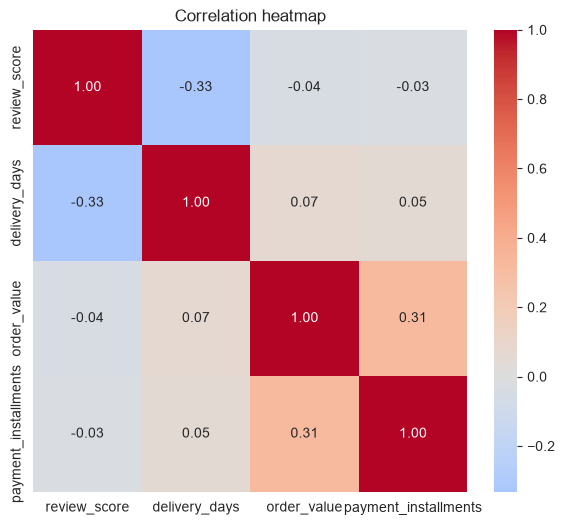

In [16]:
corr_query = """
SELECT
    r.review_score,
    EXTRACT(DAY FROM (o.order_delivered_customer_date - o.order_purchase_timestamp)) AS delivery_days,
    p.total_payment_value AS order_value,
    op.payment_installments
FROM orders o
JOIN order_reviews r ON r.order_id = o.order_id
JOIN payments_per_order p ON p.order_id = o.order_id
JOIN order_payments op ON op.order_id = o.order_id
WHERE o.order_status = 'delivered' AND o.order_delivered_customer_date IS NOT NULL;
"""

corr_df = pd.read_sql(text(corr_query), engine)

plt.figure(figsize=(7, 6))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation heatmap')
plt.show()

**Insight:** correlation giữa các biến số ở đây thường ở mức yếu-trung bình (|r| < 0.3) —
điều này khớp với trực giác rằng review score bị chi phối bởi nhiều yếu tố (chất lượng sản phẩm,
kỳ vọng cá nhân...) chứ không chỉ 1-2 biến số đơn giản. Kết luận thống kê chính thức (kèm p-value
và effect size) sẽ được thực hiện ở `02_statistical_analysis.ipynb`.

---
# 4. Outlier Analysis

IQR upper bound: 348.00
So outlier (theo IQR): 7576 (7.85%)


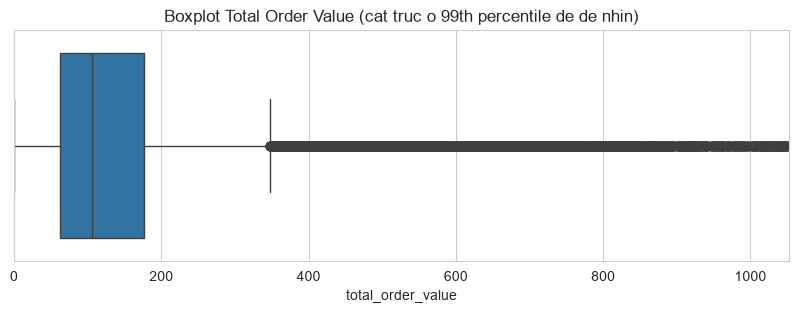

In [17]:
order_values = pd.read_sql(text('SELECT total_order_value FROM customer_order_base'), engine)

Q1 = order_values['total_order_value'].quantile(0.25)
Q3 = order_values['total_order_value'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

n_outliers = (order_values['total_order_value'] > upper_bound).sum()
pct_outliers = n_outliers / len(order_values) * 100

print(f'IQR upper bound: {upper_bound:.2f}')
print(f'So outlier (theo IQR): {n_outliers} ({pct_outliers:.2f}%)')

plt.figure(figsize=(10, 3))
sns.boxplot(x=order_values['total_order_value'])
plt.xlim(0, order_values['total_order_value'].quantile(0.99))
plt.title('Boxplot Total Order Value (cat truc o 99th percentile de de nhin)')
plt.show()

**Quyết định về outlier:** KHÔNG loại bỏ khỏi RFM — khách hàng chi tiêu rất cao chính là nhóm
quan trọng nhất cần giữ lại trong segmentation (`High-Value Potential`/`Loyal Customers`). Loại bỏ outlier ở đây sẽ
xóa mất đúng thông tin project đang tìm kiếm.

---
# 5. Kết luận tổng hợp (EDA Summary)
*(điền số liệu thật sau khi chạy notebook với dữ liệu của bạn)*

| # | Finding | Business Implication |
|---|---|---|
| 1 | ~97% đơn là `delivered` | Filter RFM hợp lệ, không mất nhiều dữ liệu |
| 2 | Order value lệch phải mạnh (mean > median) | Dùng median khi báo cáo "đơn hàng điển hình" |
| 3 | Freight chiếm ___% giá trị đơn | Cân nhắc khi so sánh revenue giữa các view khác nhau |
| 4 | Category top doanh thu: ___ | Ưu tiên tồn kho/marketing cho category này |
| 5 | Review lưỡng cực (nhiều 5 sao và 1 sao) | Điều tra riêng nhóm 1 sao |
| 6 | Delivery time trung bình ___ ngày | Đối chiếu với review score ở phần Bivariate |
| 7 | Category review thấp nhất: ___ | Ưu tiên điều tra chất lượng/vận chuyển |
| 8 | Correlation giữa các biến số ở mức yếu-trung bình | Review score bị chi phối bởi nhiều yếu tố, không chỉ 1-2 biến |
| 9 | Outlier order value không bị loại bỏ | Giữ nguyên cho bước Segmentation |

**Bước tiếp theo:** `02_statistical_analysis.ipynb` — kiểm định chính thức các quan sát ở trên
bằng test thống kê phù hợp, có effect size.